#  Prueba de segmentación de patillas

**Objetivo:**

* Lograr aislar la patilla del resto del lente que se ve en la imagen, utilizando detección de bordes y transformadad de Huge

In [2]:
# Configuración Inicial
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Checkbox, Dropdown, RadioButtons
import ipywidgets as widgets

def mostrar_imagenes(imagenes, titulos, figsize=(15, 5)):
    n = len(imagenes)
    fig, axs = plt.subplots(1, n, figsize=figsize)
    if n == 1: axs = [axs]
    for i in range(n):
        img = imagenes[i]
        if len(img.shape) == 3: img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img, cmap='gray', vmin=0, vmax=255)
        axs[i].set_title(titulos[i])
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()


print("Entorno configurado.")


Entorno configurado.


## Pre-procesamiento: aplanado de imagenes

In [3]:
def aplanar_imagen(img_objeto, img_fondo, sigma_blur=45):
    # Esta función realiza el aplanado de iluminación por división de campos (Flat-field correction).
    # 1. Convierto ambas imágenes a flotantes [0, 1] para trabajar en espacio lineal
    I_lin = img_objeto.astype(np.float32) / 255.0
    B_lin = img_fondo.astype(np.float32) / 255.0
    
    # 2. Creo el campo de iluminación lenta (le aplico un gaussiano a la imagen de fondo para suavizarla)
    kernel_size = int(sigma_blur * 3)
    if kernel_size % 2 == 0: 
        kernel_size += 1
        
    V_lin = cv2.GaussianBlur(B_lin, (kernel_size, kernel_size), sigma_blur)
    
    # 3. Divido por canal para remover la iluminación + clipping para evitar valores raros
    # Sumo un número muy chico (eps) abajo para no dividir por cero (por las dudas)
    eps = 1e-4
    img_flat = I_lin / (V_lin + eps)
    
    # Recorto los valores para que se queden estrictamente entre 0.0 y 1.0
    img_flat = np.clip(img_flat, 0.0, 1.0)
    
    # 4. Vuelvo a formato estándar de 8 bits [0, 255]
    img_flat_8u = (img_flat * 255).astype(np.uint8)
    
    return img_flat_8u

## Parte 1: Detección de bordes

Se prueba la detección de bordes con:
* Prewitt,
* Sobel,
* Laplaciano y
* Canny,


Funciones base de detectores:

In [6]:
def aplicar_prewitt(img):
    Kx_prewitt = np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]], dtype=np.float32)
    Ky_prewitt = np.array([
        [-1, -1, -1],
        [ 0,  0,  0],
        [ 1,  1,  1]], dtype=np.float32)
    prewittx = cv2.filter2D(img, cv2.CV_64F, Kx_prewitt)
    prewitty = cv2.filter2D(img, cv2.CV_64F, Ky_prewitt)
    return cv2.magnitude(prewittx, prewitty)

def aplicar_sobel(img, dx, dy, ksize, bidireccional, ddepth=cv2.CV_64F):
    if bidireccional:
        sobelx = cv2.Sobel(img, ddepth, dx=1, dy=0, ksize=ksize)
        sobely = cv2.Sobel(img, ddepth, dx=0, dy=1, ksize=ksize)

        return cv2.magnitude(sobelx.astype(np.float64), sobely.astype(np.float64))
    else:
        return cv2.Sobel(img, ddepth, dx=dx, dy=dy, ksize=ksize)

def aplicar_laplaciano(img):
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    return cv2.convertScaleAbs(laplacian)

def binarizar(img, umbral):
    img_abs = np.absolute(img)
    img_8u = cv2.normalize(img_abs, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    _, img_binaria = cv2.threshold(img_8u, umbral, 255, cv2.THRESH_BINARY)
    return img_binaria

Aplicación y muestra de los distintos detectores

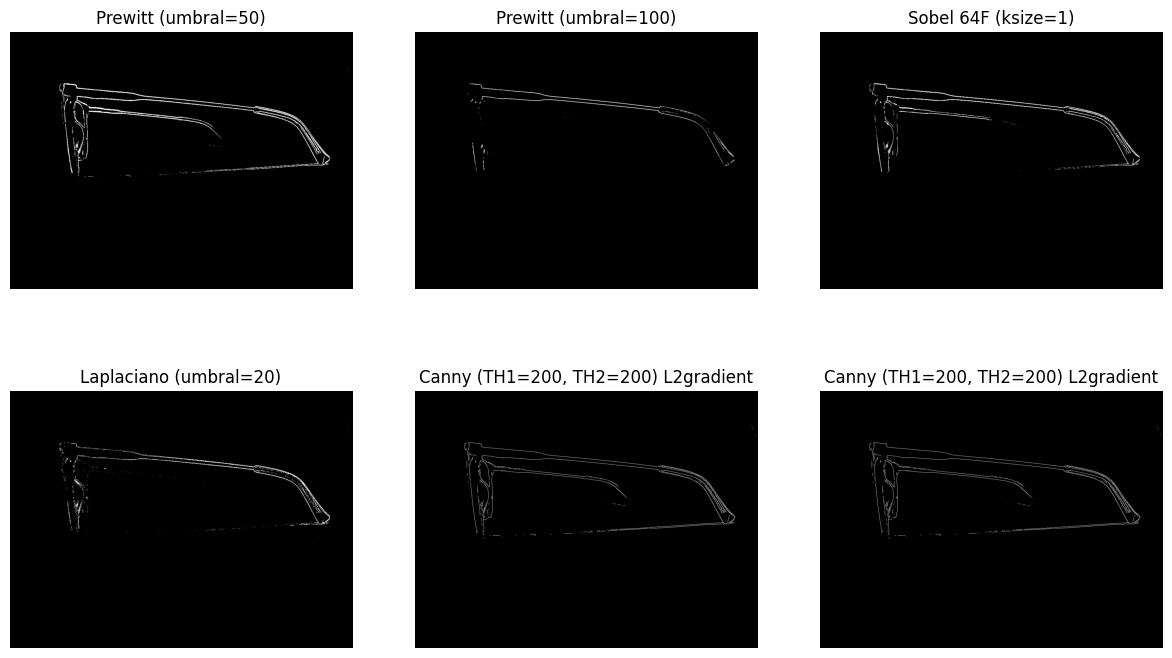

In [7]:

img_original = cv2.imread('imagenes/3-patilla.jpg', cv2.IMREAD_GRAYSCALE)
img_fondo_solo = cv2.imread('imagenes/3-fondo.jpg', cv2.IMREAD_GRAYSCALE)

# 2. Aplicar el aplanado
img_aplanada = aplanar_imagen(img_original, img_fondo_solo)
# umbrales
u_bajo = 20
u_medio = 50
u_alto = 100

# kernels
ksize_bajo = 1
ksize_medio = 5
ksize_alto = 15

# Prewitt
prewitt_mag = aplicar_prewitt(img_aplanada)

img_prewitt_2 = binarizar(prewitt_mag, u_medio)
img_prewitt_3 = binarizar(prewitt_mag, u_alto)

# Sobel
ddepth_sobel = cv2.CV_64F
sobel_1 = aplicar_sobel(img=img_aplanada, ddepth=ddepth_sobel, dx=1, dy=1, ksize=ksize_bajo, bidireccional=True)
img_sobel_1 = binarizar(sobel_1, u_medio)

# Laplaciano
laplacian = cv2.Laplacian(img_aplanada, cv2.CV_64F)

img_laplacian_1 = binarizar(laplacian, u_bajo)


# Canny
img_canny_6 = cv2.Canny(img_aplanada, 200, 200, L2gradient=True)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
plt.subplots_adjust(hspace=0.4, wspace=0.15)


ax[0,0].imshow(img_prewitt_2, cmap='gray'); ax[0,0].set_title(f"Prewitt (umbral={u_medio})"); ax[0,0].axis('off')
ax[0,1].imshow(img_prewitt_3, cmap='gray'); ax[0,1].set_title(f"Prewitt (umbral={u_alto})"); ax[0,1].axis('off')

ax[0,2].imshow(img_sobel_1, cmap='gray'); ax[0,2].set_title(f"Sobel 64F (ksize={ksize_bajo})"); ax[0,2].axis('off')


ax[1,0].imshow(img_laplacian_1, cmap='gray'); ax[1,0].set_title(f"Laplaciano (umbral={u_bajo})"); ax[1,0].axis('off')


ax[1,1].imshow(img_canny_6, cmap='gray'); ax[1,1].set_title(f"Canny (TH1={200}, TH2={200}) L2gradient"); ax[1,1].axis('off')
ax[1,2].imshow(img_canny_6, cmap='gray'); ax[1,2].set_title(f"Canny (TH1={200}, TH2={200}) L2gradient"); ax[1,2].axis('off')

plt.show()

##  Parte 2: Transformada de Hough (TH)

Detectaremos puntos colineales y segmentos utilizando la Transformada de Hough Standard y Probabilística.

In [8]:
def dibujar_hough(img, threshold, color=(255, 0, 0), bordes=None):
    if bordes is None:
        bordes = cv2.Canny(img, 50, 150, apertureSize=3)

    img_hough = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    lines = cv2.HoughLines(bordes, rho=1, theta=np.pi/180, threshold=threshold)
    for line in lines:
        rho, theta = line[0]

        # coordenadas polares a cartesianas
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho

        # lineas
        x1 = int(x0 + 10000 * (-b))
        y1 = int(y0 + 10000 * (a))
        x2 = int(x0 - 10000 * (-b))
        y2 = int(y0 - 10000 * (a))

        # Dibujamos la recta en la imagen (Color Azul en BGR)
        cv2.line(img_hough, (x1, y1), (x2, y2), color, 2)
    return img_hough

def dibujar_hough_probabilistico(img, threshold, minLineLength, maxLineGap, color=(255, 0, 0), bordes=None):
    img_hough_p = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    lines = cv2.HoughLinesP(bordes, rho=1, theta=np.pi/180, threshold=threshold, minLineLength=minLineLength, maxLineGap=maxLineGap)

    for line in lines:
        x1, y1, x2, y2 = line[0]
        # Dibujamos el segmento acotado (Color Rojo en BGR)
        cv2.line(img_hough_p, (x1, y1), (x2, y2), color, 2)

    return img_hough_p

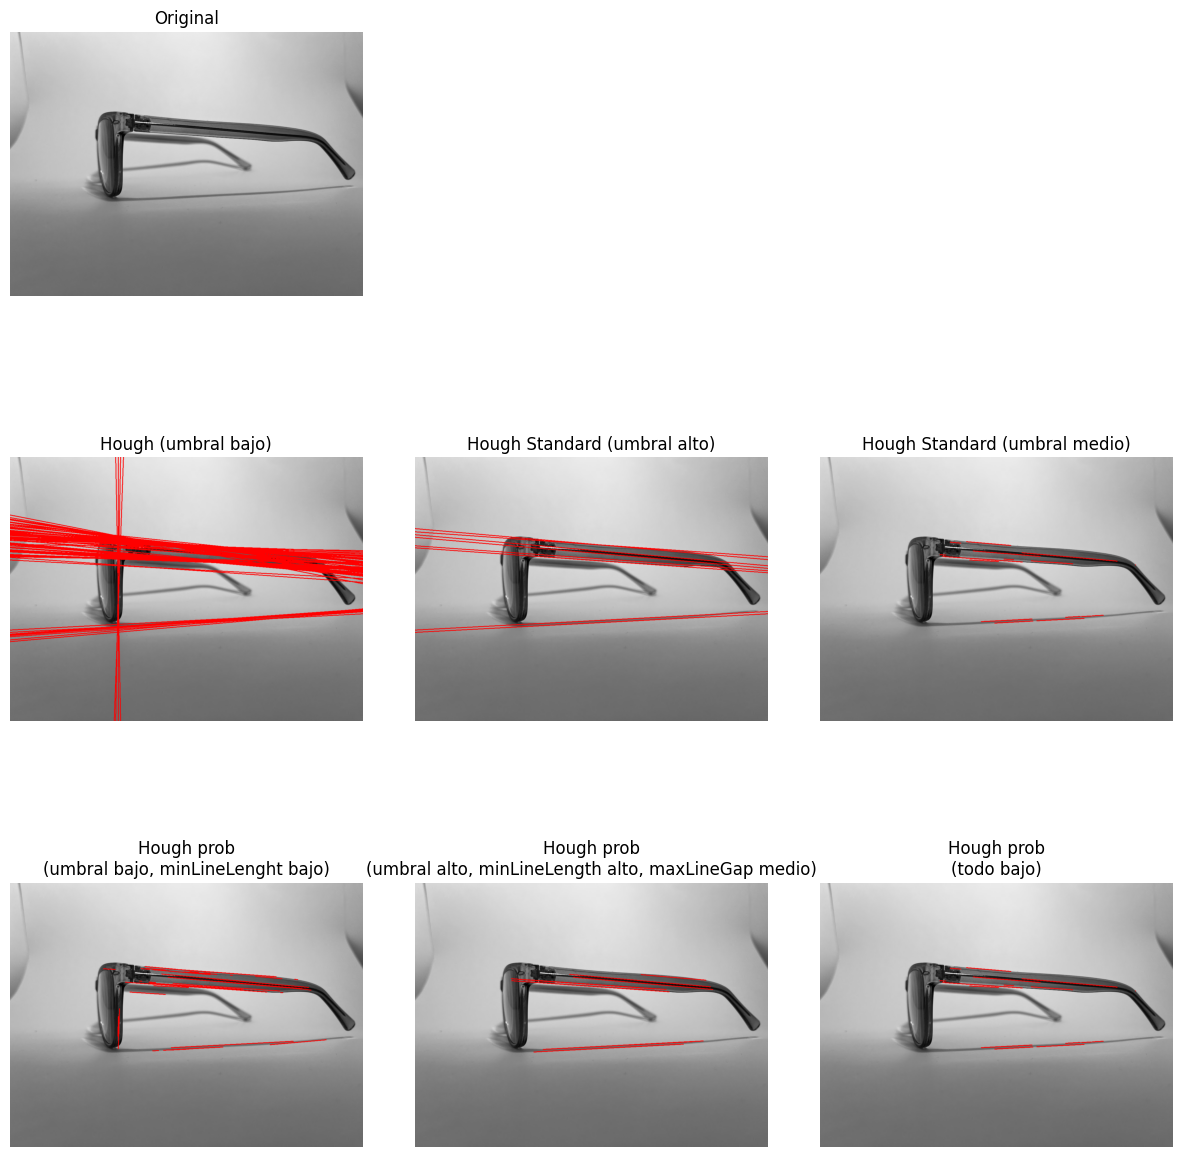

In [9]:
img = cv2.imread(f"imagenes/1-patilla.jpg", cv2.IMREAD_GRAYSCALE)
bordes = cv2.Canny(img, 50, 150, apertureSize=3)

# Hough standard
img_hough1 = dibujar_hough(img, threshold=130, bordes=bordes)
img_hough2 = dibujar_hough(img, threshold=250, bordes=bordes)
img_hough3 = dibujar_hough(img, threshold=190, bordes=bordes)

# Hough probabilistico
img_hough_p1 = dibujar_hough_probabilistico(img, threshold=130, minLineLength=1, maxLineGap=10, bordes=bordes)
img_hough_p2 = dibujar_hough_probabilistico(img, threshold=225, minLineLength=185, maxLineGap=25, bordes=bordes)
img_hough_p3 = dibujar_hough_probabilistico(img, threshold=205, minLineLength=1, maxLineGap=5, bordes=bordes)

fig, ax = plt.subplots(3, 3, figsize=(15, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.15)

ax[0,0].imshow(img, cmap='gray'); ax[0,0].set_title(f"Original"); ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[1,0].imshow(img_hough1, cmap='gray'); ax[1,0].set_title(f"Hough (umbral bajo)"); ax[1,0].axis('off')
ax[1,1].imshow(img_hough2); ax[1,1].set_title(f"Hough Standard (umbral alto)"); ax[1,1].axis('off')
ax[1,2].imshow(img_hough_p3); ax[1,2].set_title(f"Hough Standard (umbral medio)"); ax[1,2].axis('off');
ax[2,0].imshow(img_hough_p1, cmap='gray'); ax[2,0].set_title(f"Hough prob\n(umbral bajo, minLineLenght bajo)"); ax[2,0].axis('off')
ax[2,1].imshow(img_hough_p2); ax[2,1].set_title(f"Hough prob\n(umbral alto, minLineLength alto, maxLineGap medio)"); ax[2,1].axis('off')
ax[2,2].imshow(img_hough_p3); ax[2,2].set_title(f"Hough prob\n(todo bajo)"); ax[2,2].axis('off');

Ahora, la prueba con la imagen de los bordes que obtuvimos de canny

In [27]:
def aislar_patilla_inclinada(img_gris, bordes, threshold, minLineLength, maxLineGap, offset_x=15, margen_y=5):
    alto, ancho = img_gris.shape
    img_hough_p = cv2.cvtColor(img_gris, cv2.COLOR_GRAY2BGR)
    mask_corte = np.zeros_like(img_gris, dtype=np.uint8)
    
    lines = cv2.HoughLinesP(bordes, rho=1, theta=np.pi/180, 
                            threshold=threshold, 
                            minLineLength=minLineLength, 
                            maxLineGap=maxLineGap)
    
    lineas_detalladas = []
    
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            
            # 1. Calculo el ángulo real en grados (-90 a 90)
            angulo = math.atan2(y2 - y1, x2 - x1) * 180 / np.pi
            if angulo > 90: angulo -= 180
            if angulo < -90: angulo += 180
            
            # 2. Calculo el largo de la línea (Pitágoras)
            largo = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            
            # FILTRO BASE: Descartar lo que sea muy vertical (lente)
            if not (75 < abs(angulo) < 105):
                lineas_detalladas.append({
                    'puntos': (x1, y1, x2, y2),
                    'largo': largo,
                    'angulo': angulo
                })
                cv2.line(img_hough_p, (x1, y1), (x2, y2), (0, 100, 0), 1) # Feedback base

    # 3. SELECCIÓN INTELIGENTE DE TECHO Y PISO PARALELOS
    lineas_validas = []
    
    if len(lineas_detalladas) > 0:
        # Ordeno todas las líneas detectadas de Mayor a Menor largo
        lineas_detalladas.sort(key=lambda k: k['largo'], reverse=True)
        
        # La línea más larga de todas es un borde de la patilla
        linea_ancla = lineas_detalladas[0]
        lineas_validas.append(linea_ancla['puntos'])
        
        # Busco otras líneas que sean aproximadamente paralelas a la principal (Tolerancia: ±15 grados)
        angulo_referencia = linea_ancla['angulo']
        
        for l in lineas_detalladas[1:]:
            if abs(l['angulo'] - angulo_referencia) < 15: # <--- Acá defino la tolerancia
                lineas_validas.append(l['puntos'])

    #Si encuentro lineas válidas, calculo el polígono inclinado. Si no, aviso que no se pudo detectar la patilla.      
    if len(lineas_validas) > 0:
        # 1. Encuentro el corte vertical (X mínimo donde arranca la patilla)
        x_min_patilla = min(min(x1, x2) for x1, y1, x2, y2 in lineas_validas)
        x_corte = int(x_min_patilla - offset_x)
        if x_corte < 0: x_corte = 0
        
        # 2. Identifico cuál línea es la de arriba (Techo) y cuál la de abajo (Piso)
        # Para saberlo con inclinación, evalúo el valor de Y en el centro de la pantalla (x = ancho // 2)
        x_mid = ancho // 2
        
        lineas_con_y_centro = []
        for x1, y1, x2, y2 in lineas_validas:
            # Evitar división por cero si quedó alguna mini vertical
            if x2 == x1: x2 += 1 
            # Calcular pendiente (m) y ordenada al origen (b) -> y = mx + b
            m = (y2 - y1) / (x2 - x1)
            b = y1 - m * x1
            # Proyecto cuánto valdría Y en el medio de la imagen para comparar alturas reales
            y_centro = m * x_mid + b
            lineas_con_y_centro.append((y_centro, m, b))
            
        # Ordeno por su altura en el centro (menor Y es más arriba en la pantalla)
        lineas_con_y_centro.sort(key=lambda item: item[0])
        
        # Guardo las ecuaciones de la recta más alta y la más baja
        _, m_techo, b_techo = lineas_con_y_centro[0]
        _, m_piso, b_piso = lineas_con_y_centro[-1]
        
        # 3. Calcular las esquinas del polígono inclinado (en X_corte y en el Ancho total)
        # Esquina superior izquierda (en el corte)
        y_sup_izq = int(m_techo * x_corte + b_techo) - margen_y
        # Esquina superior derecha (al final de la foto)
        y_sup_der = int(m_techo * ancho + b_techo) - margen_y
        # Esquina inferior derecha (al final de la foto)
        y_inf_der = int(m_piso * ancho + b_piso) + margen_y
        # Esquina inferior izquierda (en el corte)
        y_inf_izq = int(m_piso * x_corte + b_piso) + margen_y
        
        # 4. CREAR MÁSCARA POLIGONAL INCLINADA
        # Definimos los 4 puntos del trapecio inclinado
        puntos_poligono = np.array([
            [x_corte, y_sup_izq],  # Sup Izq
            [ancho, y_sup_der],    # Sup Der
            [ancho, y_inf_der],    # Inf Der
            [x_corte, y_inf_izq]   # Inf Izq
        ], dtype=np.int32)
        
        # Rellenamos el polígono con blanco en la máscara
        cv2.fillPoly(mask_corte, [puntos_poligono], int(cv2.mean(img_gris)[0]))
        
        # --- Dibujo cosmético de las líneas de corte reales en el feedback ---
        cv2.line(img_hough_p, (x_corte, max(0, y_sup_izq)), (x_corte, min(alto, y_inf_izq)), (0, 0, 255), 3) # Corte vertical
        cv2.line(img_hough_p, (x_corte, y_sup_izq), (ancho, y_sup_der), (255, 0, 0), 2) # Techo inclinado
        cv2.line(img_hough_p, (x_corte, y_inf_izq), (ancho, y_inf_der), (255, 0, 0), 2) # Piso inclinado
        
        print(f"-> Polígono calculado con éxito siguiendo la inclinación de la patilla.")
    else:
        print("-> No se detectaron líneas válidas para la patilla.")

    # 5. Aplicar la máscara inclinada
    gris_fondo = int(cv2.mean(img_gris)[0])
    
    # 2. Creamos un lienzo de fondo completo con ese color gris
    fondo_gris_completo = np.full_like(img_gris, gris_fondo)
    
    # 3. Creamos la máscara inversa (blanco lo de afuera, negro el trapecio)
    mask_corte_inversa = cv2.bitwise_not(mask_corte)
    
    # 4. De la imagen original, nos quedamos SOLO con la patilla (lo de afuera queda negro)
    solo_patilla = cv2.bitwise_and(img_gris, img_gris, mask=mask_corte)
    
    # 5. Del lienzo gris, nos quedamos SOLO con lo de afuera (el trapecio queda negro)
    solo_fondo_gris = cv2.bitwise_and(fondo_gris_completo, fondo_gris_completo, mask=mask_corte_inversa)
    
    # 6. Sumamos ambas imágenes: la patilla encastra perfecto en el hueco del fondo gris
    patilla_aislada = cv2.add(solo_patilla, solo_fondo_gris)
    
    return img_hough_p, mask_corte, patilla_aislada

-> Polígono calculado con éxito siguiendo la inclinación de la patilla.
-> Objeto predominante aislado con éxito. Área: 554805.5 px.


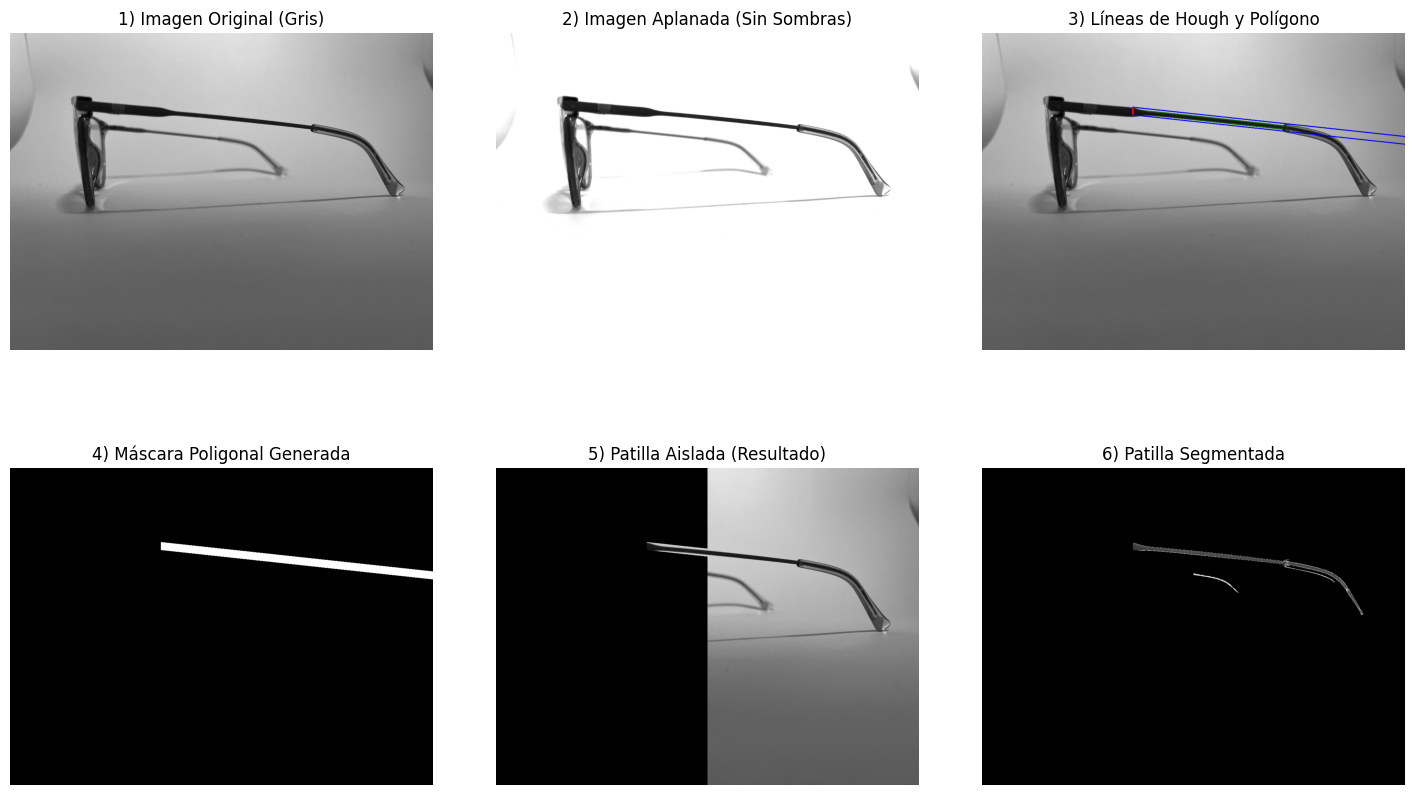

In [36]:
# Cargamos la imagen base en escala de grises (la que le dio origen a tus canny)
#img_original_gris = cv2.imread("imagenes/1-patilla.jpg", cv2.IMREAD_GRAYSCALE)
img_original = cv2.imread('imagenes/3-patilla.jpg', cv2.IMREAD_GRAYSCALE)
img_fondo_solo = cv2.imread('imagenes/3-fondo.jpg', cv2.IMREAD_GRAYSCALE)

# 2. Aplicar el aplanado
img_aplanada = aplanar_imagen(img_original, img_fondo_solo)

# umbrales
u_bajo = 20
u_medio = 50
u_alto = 100

# kernels
ksize_bajo = 1
ksize_medio = 5
ksize_alto = 15

# Prewitt
prewitt_mag = aplicar_prewitt(img_aplanada)

img_prewitt_2 = binarizar(prewitt_mag, u_medio)
img_prewitt_3 = binarizar(prewitt_mag, u_alto)

# Sobel
ddepth_sobel = cv2.CV_64F
sobel_1 = aplicar_sobel(img=img_aplanada, ddepth=ddepth_sobel, dx=1, dy=1, ksize=ksize_bajo, bidireccional=True)
img_sobel_1 = binarizar(sobel_1, u_medio)

# Laplaciano
laplacian = cv2.Laplacian(img_aplanada, cv2.CV_64F)

img_laplacian_1 = binarizar(laplacian, u_bajo)


# Canny
img_canny_6 = cv2.Canny(img_aplanada, 200, 200, L2gradient=True)
# Ejecutamos el algoritmo usando tus bordes limpios (img_canny_6)
img_lineas, mascara, resultado_final = aislar_patilla_inclinada(
    img_gris=img_original, 
    bordes=img_laplacian_1,           
    threshold=150,                
    minLineLength=100,            
    maxLineGap=15,                
    offset_x=15,               
    margen_y=5
)

alto, ancho = img_original.shape
x_medio = ancho // 2

# 3. Clono la máscara para no romper la imagen de feedback visual
mascara_mitad_izquierda = mascara.copy()

# 4. Pinto de blanco (255) toda la mitad derecha [filas, columnas]
mascara_mitad_izquierda[:, x_medio:] = 255

# 5. Aplico la nueva máscara modificada a la imagen original
resultado_final = cv2.bitwise_and(img_original, img_original, mask=mascara_mitad_izquierda)

# --- 1. DETECCIÓN DEL OBJETO PREDOMINANTE (LA PATILLA) ---

# Uso la imagen aplanada recortada por la máscara para que tenga buen contraste
img_recortada_zona = cv2.bitwise_and(img_aplanada, img_aplanada, mask=mascara_mitad_izquierda)

# Binarización (Otsu suele ser mágico acá porque calcula el umbral perfecto automáticamente)
_, patilla_binaria = cv2.threshold(img_recortada_zona, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

patilla_binaria = cv2.bitwise_not(patilla_binaria)

# Busco los contornos (las islas de píxeles blancos)
contornos, _ = cv2.findContours(patilla_binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Cros una máscara vacía (toda negra) del mismo tamaño que la foto
mascara_objeto_predominante = np.zeros_like(img_original, dtype=np.uint8)

if len(contornos) > 0:
    # Contorno mas grande
    contorno_patilla = max(contornos, key=cv2.contourArea)
    
    # Dibujo SOLO ese contorno relleno de blanco (255) en la nueva máscara limpia
    cv2.drawContours(mascara_objeto_predominante, [contorno_patilla], -1, 255, thickness=cv2.FILLED)
    print(f"-> Objeto predominante aislado con éxito. Área: {cv2.contourArea(contorno_patilla)} px.")
else:
    print("-> No se encontraron objetos aislados en la zona.")

# --- 2. RECORTE FINAL ABSOLUTO ---
# Ahora aplico la máscara ultra limpia a la imagen original en gris
patilla_perfecta = cv2.bitwise_and(img_original, img_original, mask=mascara_objeto_predominante)

# Por alguna razón tengo que volver a aplicar la máscara de la mitad izquierda para que quede bien recortada
resultado_final2 = cv2.bitwise_and(patilla_perfecta, patilla_perfecta, mask=mascara_mitad_izquierda)


#------ Grafico los resultados ------#

# Definimos una ventana ancha (18) y chata (10) para evitar súper espacios
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.15)

# --- FILA 0 ---
# 1) Imagen Original
ax[0, 0].imshow(img_original, cmap='gray')
ax[0, 0].set_title("1) Imagen Original (Gris)")
ax[0, 0].axis('off')

# 2) Imagen Aplanada
ax[0, 1].imshow(img_aplanada, cmap='gray')
ax[0, 1].set_title("2) Imagen Aplanada (Sin Sombras)")
ax[0, 1].axis('off')

# 3) Líneas Detectadas (Hough) - Esta está en BGR/RGB porque tiene líneas de color
# Convertimos de BGR (OpenCV) a RGB para que Matplotlib muestre bien el rojo y verde
img_lineas_rgb = cv2.cvtColor(img_lineas, cv2.COLOR_BGR2RGB)
ax[0, 2].imshow(img_lineas_rgb)
ax[0, 2].set_title("3) Líneas de Hough y Polígono")
ax[0, 2].axis('off')


# --- FILA 1 ---
# 4) Máscara Binaria
ax[1, 0].imshow(mascara, cmap='gray')
ax[1, 0].set_title("4) Máscara Poligonal Generada")
ax[1, 0].axis('off')

# 5) Recorte Final
ax[1, 1].imshow(resultado_final, cmap='gray')
ax[1, 1].set_title("5) Patilla Aislada (Resultado)")
ax[1, 1].axis('off')

# 6) Patilla Segmentada
ax[1, 2].imshow(resultado_final2, cmap='gray')
ax[1, 2].set_title("6) Patilla Segmentada")
ax[1, 2].axis('off')


plt.show()